In [6]:
from Train.train_spikemo import Config, Trainer
from Train.notebook_utils import load_val_data, evaluate_model

In [7]:
import torch


# Initialize config and trainer
config = Config()
trainer = Trainer(config)

# Load your best checkpoint
checkpoint_path = r"C:\Users\Marc\Desktop\Programming\SNN-Research\final\checkpoints\SpikEmo_T8_dim256_h4_lr4.9334886565290195e-05_bs32_20260321_095310\checkpoint_epoch48_f10.7725.pt" # Replace with your actual path
trainer.model.load_state_dict(torch.load(checkpoint_path))
model = trainer.model


Loaded 1487 validation samples.
Running inference...


  0%|          | 0/47 [00:00<?, ?it/s]

100%|██████████| 47/47 [00:04<00:00, 10.77it/s]



Accuracy: 0.7727
F1 Score (Weighted): 0.7725

Classification Report:
              precision    recall  f1-score   support

       angry       0.86      0.86      0.86       244
     disgust       0.73      0.81      0.77       262
        fear       0.73      0.67      0.70       256
       happy       0.82      0.80      0.81       249
     neutral       0.81      0.76      0.78       215
         sad       0.70      0.73      0.72       261

    accuracy                           0.77      1487
   macro avg       0.78      0.77      0.77      1487
weighted avg       0.77      0.77      0.77      1487



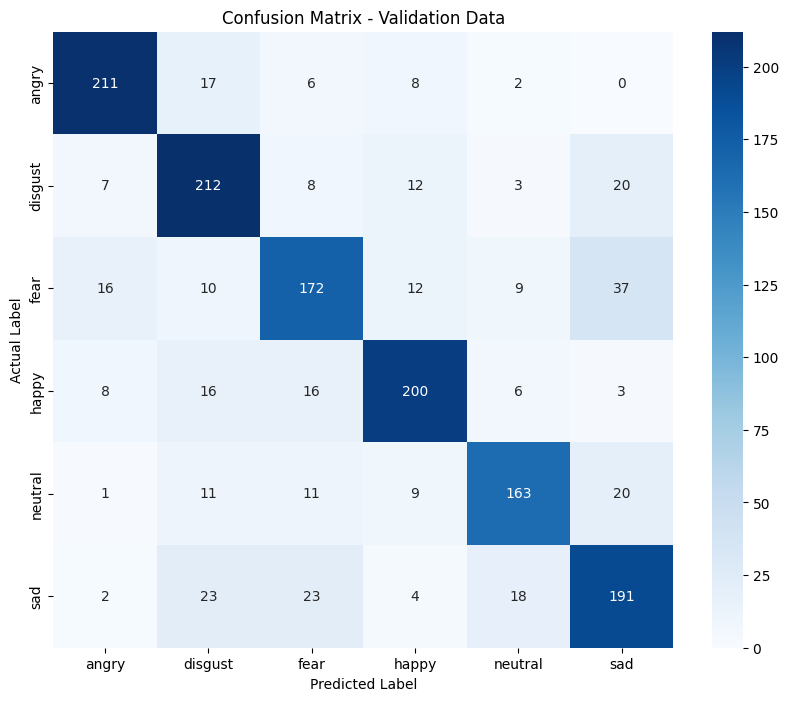

In [8]:
# 1. Load the validation data
val_loader = load_val_data(feature_root="features", batch_size=32)

# 2. Run evaluation and plot confusion matrix
results = evaluate_model(model, val_loader, device="cuda")


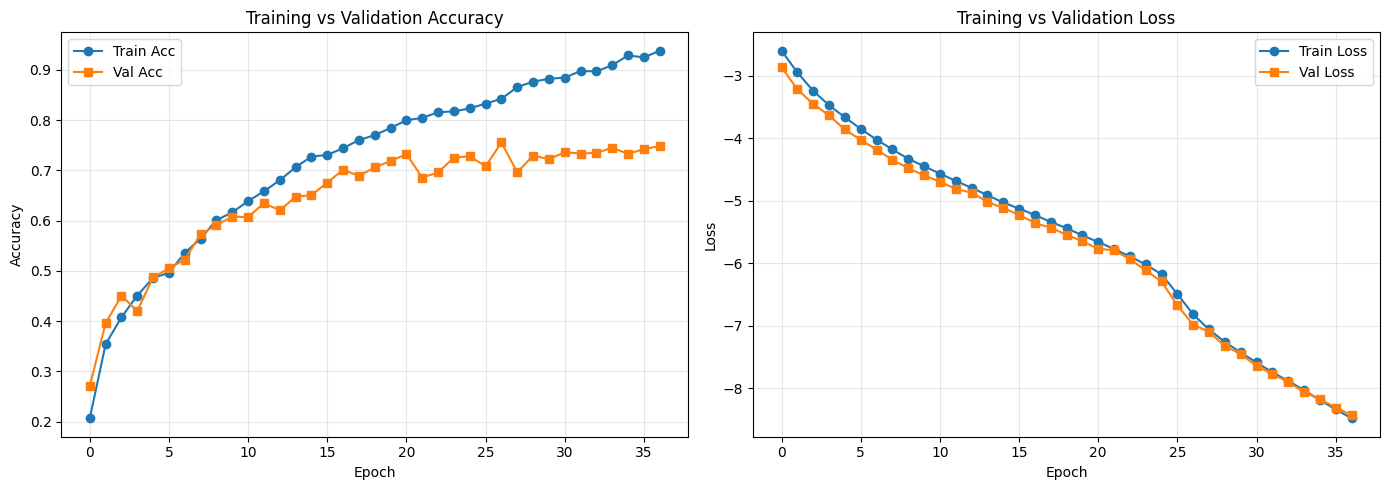

Plotted metrics from run: SpikEmo_T8_dim256_h4_lr4.9334886565290195e-05_bs32_20260320_233552


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

# Set tracking URI
mlflow.set_tracking_uri("sqlite:///snn.db")
client = MlflowClient()

# Get your SpikEmo experiment
experiment = client.get_experiment_by_name("SpikEmo_SNN")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

# Extract metrics from the best run (or specific run)
best_run = max(runs, key=lambda r: float(r.data.metrics.get("best_val_f1", 0)))

# Get all metric history for this run
run_id = best_run.info.run_id
metrics_history = client.get_run(run_id).data.metrics

# Query the database for step-wise metrics
import sqlite3
conn = sqlite3.connect('snn.db')
query = """
    SELECT key, value, step 
    FROM metrics 
    WHERE run_uuid = ? 
    ORDER BY step
"""
df_metrics = pd.read_sql_query(query, conn, params=(run_id,))
conn.close()

# Pivot data for plotting
df_pivot = df_metrics.pivot_table(index='step', columns='key', values='value', aggfunc='last')

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
axes[0].plot(df_pivot.index, df_pivot['train_acc'], label='Train Acc', marker='o')
axes[0].plot(df_pivot.index, df_pivot['val_acc'], label='Val Acc', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss
axes[1].plot(df_pivot.index, df_pivot['train_loss'], label='Train Loss', marker='o')
axes[1].plot(df_pivot.index, df_pivot['val_loss'], label='Val Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Plotted metrics from run: {best_run.info.run_name}")